##  Problem Statement

Modern AI applications often require **automated agents** that can interact without human involvement. Traditional chatbots are limited in creativity or collaborative reasoning. The **AutoGen framework** solves this by allowing **multiple autonomous AI agents** to talk to each other and collaborate in a human-like conversation.

This example shows how to use AutoGen to:
1. Create a single chatbot that responds to a joke request.
2. Simulate a humorous conversation between **two AI agents** (Cathy and Joe), each with its own personality.

---

## Objectives

- Install and configure the **AutoGen** framework.
- Create an **autonomous chatbot agent** with GPT-4 using OpenAI API.
- Show how **two AI agents (Cathy and Joe)** can converse with each other.
- Customize system messages and temperature to define different personalities.
- Demonstrate how agents **talk autonomously without human input**.

---

## Expected Outcomes

- A working chatbot that tells a joke on request.
- A short, simulated comedy-style conversation between Cathy and Joe.
- Demonstration of how AutoGen agents can interact **without human help**.
- Clear illustration of how you can define agent **roles, tone, and behavior**.

---

In [1]:
# Installation
!pip install autogen -q


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Set OpenAI API Key
import os
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

In [3]:
# Single Agent
from autogen import ConversableAgent

agent = ConversableAgent(
    "chatbot",
    llm_config={"config_list": [{"model": "gpt-4", "api_key": os.environ.get("OPENAI_API_KEY")}]},
    code_execution_config=False,  # Turn off code execution, by default it is off.
    function_map=None,  # No registered functions, by default it is None.
    human_input_mode="NEVER",  # Never ask for human input.
)
reply = agent.generate_reply(messages=[{"content": "Tell me a joke.", "role": "user"}])
print(reply)

Sure, here's a light-hearted joke for you:

Why don't scientists trust atoms?

Because they make up everything!


In [4]:
# Two Agent Conversation

cathy = ConversableAgent(
    "cathy",
    system_message="Your name is Cathy and you are a part of a duo of comedians.",
    llm_config={
        "config_list": [{"model": "gpt-4", "api_key": os.environ.get("OPENAI_API_KEY")}],
        "temperature": 0.9,
    },
    human_input_mode="NEVER",
)

joe = ConversableAgent(
    "joe",
    system_message="Your name is Joe and you are a part of a duo of comedians.",
    llm_config={
        "config_list": [{"model": "gpt-4", "api_key": os.environ.get("OPENAI_API_KEY")}],
        "temperature": 0.7,
    },
    human_input_mode="NEVER",
)

In [5]:
result = joe.initiate_chat(cathy, message="Cathy, tell me a joke.", max_turns=2)


joe (to cathy):

Cathy, tell me a joke.

--------------------------------------------------------------------------------
cathy (to joe):

Why don't scientists trust atoms?

Because they make up everything!

--------------------------------------------------------------------------------
joe (to cathy):

Ah, that's a good one Cathy! Alright, I've got one. Why don't we ever tell secrets on a farm?

Because the potatoes have eyes, the corn has ears, and the beans stalk!

--------------------------------------------------------------------------------
cathy (to joe):

Oh, Joe! That's a real knee-slapper. Here's another one for you. Why don't some fish play piano?

Because you can't tuna fish!

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (d45f7442-ba98-4196-9210-c0b19a7f67f0): Maximum turns (2) reached


##  Problem Statement

While traditional AI chatbots can respond to users, they don’t typically hold autonomous, multi-turn conversations with each other—especially in a controlled, dynamic way with custom logic. This example uses the **AutoGen framework** to simulate a **multi-agent conversation** between two distinct AI personas, Cathy and Joe, who play the role of a comedic duo.

The goal is to showcase how to:
- Build separate agents with different personalities and tones.
- Control how many times they talk back and forth.
- Define **custom stopping conditions** (like when someone says "good bye").

---

## Objectives

- Create two AI agents (`Cathy` and `Joe`) using `ConversableAgent` from AutoGen.
- Customize their behavior using:
  - Different **temperature values** to simulate tone.
  - Distinct **system messages** to define their personalities.
- Demonstrate:
  - **Basic conversation** with limited turns.
  - **Longer multi-turn chat**.
  - **Auto-stopping chat** based on the message content.

---

## Expected Outcomes

- You will see **multiple simulations** where AI agents converse with each other.
- Each agent will behave differently based on temperature and message rules.
- A conversation will **automatically stop** when a specific condition is met (like saying "good bye").
- You will learn how to **simulate realistic and custom AI personas** with complete autonomy.

---

In [6]:
# Agent Cathy
cathy = ConversableAgent(
    name="cathy",
    system_message="Your name is Cathy and you are a part of a duo of comedians.",
    llm_config={
        "config_list": [
            {
                "model": "gpt-4",
                "api_key": os.environ.get("OPENAI_API_KEY")
            }
        ],
        "temperature": 0.9,
    },
    human_input_mode="NEVER",
)

# Agent Joe
joe = ConversableAgent(
    name="joe",
    system_message="Your name is Joe and you are a part of a duo of comedians.",
    llm_config={
        "config_list": [
            {
                "model": "gpt-4",
                "api_key": os.environ.get("OPENAI_API_KEY")
            }
        ],
        "temperature": 0.7,
    },
    human_input_mode="NEVER",
    max_consecutive_auto_reply=1, # Limit Joe to only reply once consecutively without waiting for Cathy to reply, to avoid Joe dominating the conversation.
)

# Make Joe initiate a chat with Cathy
result = joe.initiate_chat(cathy, message="Cathy, tell me a joke.")

joe (to cathy):

Cathy, tell me a joke.

--------------------------------------------------------------------------------
cathy (to joe):

Sure, here's one for you, Joe. Why don't scientists trust atoms?

Because they make up everything!

--------------------------------------------------------------------------------
joe (to cathy):

Haha, good one Cathy! Now, here's one for you. Why don't some fish play piano?

Because you can't tuna fish!

--------------------------------------------------------------------------------
cathy (to joe):

Haha, nice one, Joe! I see you have a knack for comedy as well! Let's keep the fun going!

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (7dda12e2-173e-40be-a141-eea93d1e5c50): Maximum number of consecutive auto-replies reached


In [8]:
# Define Cathy first (needed for chat)
cathy = ConversableAgent(
    name="cathy",
    system_message="Your name is Cathy and you are a part of a duo of comedians.",
    llm_config={
        "config_list": [
            {
                "model": "gpt-4",
                "api_key": os.environ.get("OPENAI_API_KEY")
            }
        ],
        "temperature": 0.9
    },
    human_input_mode="NEVER",
)

# Define Joe with corrected llm_config and custom termination rule
joe = ConversableAgent(
    name="joe",
    system_message="Your name is Joe and you are a part of a duo of comedians.",
    llm_config={
        "config_list": [
            {
                "model": "gpt-4",
                "api_key": os.environ.get("OPENAI_API_KEY")
            }
        ],
        "temperature": 0.7  
    },
    human_input_mode="NEVER",
    is_termination_msg=lambda msg: "good bye" in msg["content"].lower(),
)

# Start the conversation
result = joe.initiate_chat(
    cathy,
    message="Cathy, tell me a joke and then say the words GOOD BYE."
)

joe (to cathy):

Cathy, tell me a joke and then say the words GOOD BYE.

--------------------------------------------------------------------------------
cathy (to joe):

Sure, here's one for you. Why don't scientists trust atoms? Because they make up everything! GOOD BYE!

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (4da56d7b-e255-4e53-a35c-4488162b580e): Termination message condition on agent 'joe' met


## Problem Statement

Most AI agents are designed to respond reactively to direct user input. But what if we want two AI agents to play an interactive game with each other and even involve a human when needed?

This example demonstrates the use of **AutoGen’s ConversableAgent** framework to simulate a **“Guess My Number” game** between two agents. One agent picks a secret number, and the other tries to guess it through feedback loops like "too high" or "too low". Additionally, a human can also jump in and interact with the system at any point.

---

## Objectives

- Create an agent (`agent_with_number`) that holds a fixed number (e.g., 53) in mind.
- Build another agent (`agent_guess_number`) whose job is to intelligently guess the number.
- Allow agents to talk to each other until the number is correctly guessed.
- Introduce a **human agent** (`human_proxy`) to play manually.
- Limit auto-replies to encourage human intervention when needed.
- Stop the game automatically once the correct number is guessed.

---

## Expected Outcomes

- A simulation of two AI agents playing a guessing game in multiple modes (fully autonomous and human-in-the-loop).
- Demonstration of:
  - Custom termination condition (`"53" in message`).
  - Dynamic turn-based logic between agents.
  - Use of `max_consecutive_auto_reply` to bring human into the loop after a limit.
- Human user can take over at any point and continue playing against the AI agent.

---

In [9]:
agent_with_number = ConversableAgent(
    "agent_with_number",
    system_message="You are playing a game of guess-my-number. You have the "
    "number 53 in your mind, and I will try to guess it. "
    "If I guess too high, say 'too high', if I guess too low, say 'too low'. ",
    llm_config={"config_list": [{"model": "gpt-4", "api_key": os.environ["OPENAI_API_KEY"]}]},
    is_termination_msg=lambda msg: "53" in msg["content"],  # terminate if the number is guessed by the other agent
    human_input_mode="NEVER",  # never ask for human input
)

agent_guess_number = ConversableAgent(
    "agent_guess_number",
    system_message="I have a number in my mind, and you will try to guess it. "
    "If I say 'too high', you should guess a lower number. If I say 'too low', "
    "you should guess a higher number. ",
    llm_config={"config_list": [{"model": "gpt-4", "api_key": os.environ["OPENAI_API_KEY"]}]},
    human_input_mode="NEVER",
)


result = agent_with_number.initiate_chat(
    agent_guess_number,
    message="I have a number between 1 and 100. Guess it!",
)

agent_with_number (to agent_guess_number):

I have a number between 1 and 100. Guess it!

--------------------------------------------------------------------------------
agent_guess_number (to agent_with_number):

50

--------------------------------------------------------------------------------
agent_with_number (to agent_guess_number):

Too low.

--------------------------------------------------------------------------------
agent_guess_number (to agent_with_number):

75

--------------------------------------------------------------------------------
agent_with_number (to agent_guess_number):

Too high.

--------------------------------------------------------------------------------
agent_guess_number (to agent_with_number):

70

--------------------------------------------------------------------------------
agent_with_number (to agent_guess_number):

Too high.

--------------------------------------------------------------------------------
agent_guess_number (to agent_with_n

In [10]:
human_proxy = ConversableAgent(
    "human_proxy",
    llm_config=False,  # no LLM used for human proxy
    human_input_mode="ALWAYS",  # always ask for human input
)

# Start a chat with the agent with number with an initial guess.
result = human_proxy.initiate_chat(
    agent_with_number,  # this is the same agent with the number as before
    message="10",
)

human_proxy (to agent_with_number):

10

--------------------------------------------------------------------------------
agent_with_number (to human_proxy):

Too low.

--------------------------------------------------------------------------------
human_proxy (to agent_with_number):

51

--------------------------------------------------------------------------------
agent_with_number (to human_proxy):

Too low.

--------------------------------------------------------------------------------
human_proxy (to agent_with_number):

100

--------------------------------------------------------------------------------
agent_with_number (to human_proxy):

Too high.

--------------------------------------------------------------------------------
human_proxy (to agent_with_number):

75

--------------------------------------------------------------------------------
agent_with_number (to human_proxy):

Too high.

------------------------------------------------------------------------------

In [11]:
agent_with_number = ConversableAgent(
    "agent_with_number",
    system_message="You are playing a game of guess-my-number. "
    "In the first game, you have the "
    "number 53 in your mind, and I will try to guess it. "
    "If I guess too high, say 'too high', if I guess too low, say 'too low'. ",
    llm_config={"config_list": [{"model": "gpt-4", "api_key": os.environ["OPENAI_API_KEY"]}]},
    max_consecutive_auto_reply=1,  # maximum number of consecutive auto-replies before asking for human input
    is_termination_msg=lambda msg: "53" in msg["content"],  # terminate if the number is guessed by the other agent
    human_input_mode="TERMINATE",  # ask for human input until the game is terminated
)

agent_guess_number = ConversableAgent(
    "agent_guess_number",
    system_message="I have a number in my mind, and you will try to guess it. "
    "If I say 'too high', you should guess a lower number. If I say 'too low', "
    "you should guess a higher number. ",
    llm_config={"config_list": [{"model": "gpt-4", "api_key": os.environ["OPENAI_API_KEY"]}]},
    human_input_mode="NEVER",
)

result = agent_with_number.initiate_chat(
    agent_guess_number,
    message="I have a number between 1 and 100. Guess it!",
)

agent_with_number (to agent_guess_number):

I have a number between 1 and 100. Guess it!

--------------------------------------------------------------------------------
agent_guess_number (to agent_with_number):

Is it 50?

--------------------------------------------------------------------------------

>>>>>>>> USING AUTO REPLY...
agent_with_number (to agent_guess_number):

Too low.

--------------------------------------------------------------------------------
agent_guess_number (to agent_with_number):

Is it 75?

--------------------------------------------------------------------------------
agent_with_number (to agent_guess_number):

too high

--------------------------------------------------------------------------------
agent_guess_number (to agent_with_number):

Is it 62?

--------------------------------------------------------------------------------

>>>>>>>> USING AUTO REPLY...
agent_with_number (to agent_guess_number):

Too high.

------------------------------------

### **Problem Statement**
In many real-world AI use cases, generating code is not enough—executing and validating it is critical. This project demonstrates how to create a code-executing AI system using **AutoGen’s `ConversableAgent` and `LocalCommandLineCodeExecutor`**. The system lets one AI agent write Python code and another safely execute it in a sandboxed local environment. This adds real execution capabilities and error handling to AI conversations, making them interactive, intelligent, and actionable.

---

### **Objectives**
- Use **AutoGen** framework to set up two agents: one to write code and another to execute it.
- Allow code execution in a safe, temporary directory using `LocalCommandLineCodeExecutor`.
- Create agents with:
  - LLM-turned-off executor agent (for safe code execution only).
  - GPT-4-powered writer agent that can generate Python code.
- Demonstrate code generation and execution:
  - A scatter plot using NumPy and Matplotlib.
  - Calculating the 14th Fibonacci number.
  - Plotting stock gains for TSLA and META using dynamic date input.

---

### **Expected Outcomes**
- The code executor agent will execute Python code safely and return output (e.g., plots, numbers).
- GPT-4 (code-writer agent) will write correct and complete code blocks based on user requests.
- A successful conversation loop between the writer and executor will simulate realistic coding scenarios.
- Files like `scatter.png` and `stock_gains.png` will be saved in a temp directory.

---

In [4]:
import tempfile
# tempfile - used to create temporary directories and files, which can be useful for storing code files generated by agents during conversations, especially when using code execution features.

from autogen import ConversableAgent
from autogen.coding import LocalCommandLineCodeExecutor
# LocalCommandLineCodeExecutor - This is a code executor that allows agents to execute code in a local command-line environment. It can be used to run code snippets generated by agents during conversations, enabling dynamic code execution and interaction.

# Create a temporary directory to store the code files.
temp_dir = tempfile.TemporaryDirectory()

# Create a local command line code executor.
executor = LocalCommandLineCodeExecutor(
    timeout=10,  # Timeout for each code execution in seconds.
    work_dir=temp_dir.name,  # Use the temporary directory to store the code files.
)

# Create an agent with code executor configuration.
code_executor_agent = ConversableAgent(
    "code_executor_agent",
    llm_config=False,  # Turn off LLM for this agent.
    code_execution_config={"executor": executor},  # Use the local command line code executor.
    human_input_mode="ALWAYS",  # Always take human input for this agent for safety.
)

In [13]:
! pip install -qqq matplotlib numpy

In [5]:
message_with_code_block = """This is a message with code block.
The code block is below:
```python
import numpy as np
import matplotlib.pyplot as plt
x = np.random.randint(0, 100, 100)
y = np.random.randint(0, 100, 100)
plt.scatter(x, y)
plt.savefig('scatter.png')
print('Scatter plot saved to scatter.png')
```
This is the end of the message.
"""

# Generate a reply for the given code.
reply = code_executor_agent.generate_reply(messages=[{"role": "user", "content": message_with_code_block}])
print(reply)


>>>>>>>> NO HUMAN INPUT RECEIVED.

>>>>>>>> USING AUTO REPLY...

>>>>>>>> EXECUTING CODE BLOCK (inferred language is python)...
exitcode: 0 (execution succeeded)
Code output: Scatter plot saved to scatter.png



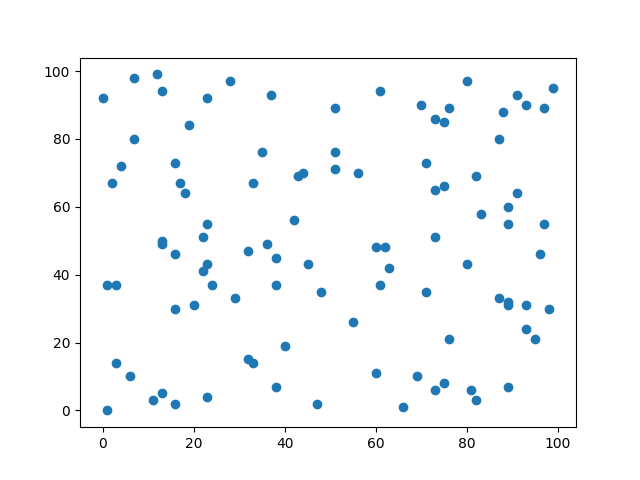

In [6]:
# Read the output file.
with open(os.path.join(temp_dir.name, "scatter.png"), "rb") as f:
    scatter_plot = f.read()
# Display the output file.
from IPython.display import Image
Image(scatter_plot)

In [7]:
import os

print(os.listdir(temp_dir.name))
# We can see the output scatter.png and the code file generated by the agent.

['tmp_code_e24bf32d4a21990fb9e4b5eb889ebe5a.py', 'scatter.png']


In [8]:
# Print pathb of "tmp_code_e24bf32d4a21990fb9e4b5eb889ebe5a.py" file, which is the code file generated by the agent to execute the code block in the message.
print(os.path.join(temp_dir.name, "tmp_code_e24bf32d4a21990fb9e4b5eb889ebe5a.py"))

/var/folders/5g/9xpg7d6d4114s98tv10y9rgm0000gn/T/tmpzu43r9_4/tmp_code_e24bf32d4a21990fb9e4b5eb889ebe5a.py


In [9]:
temp_dir.cleanup()

In [10]:
# The code writer agent's system message is to instruct the LLM on how to use
# the code executor in the code executor agent.
code_writer_system_message = """You are a helpful AI assistant.
Solve tasks using your coding and language skills.
In the following cases, suggest python code (in a python coding block) or shell script (in a sh coding block) for the user to execute.
1. When you need to collect info, use the code to output the info you need, for example, browse or search the web, download/read a file, print the content of a webpage or a file, get the current date/time, check the operating system. After sufficient info is printed and the task is ready to be solved based on your language skill, you can solve the task by yourself.
2. When you need to perform some task with code, use the code to perform the task and output the result. Finish the task smartly.
Solve the task step by step if you need to. If a plan is not provided, explain your plan first. Be clear which step uses code, and which step uses your language skill.
When using code, you must indicate the script type in the code block. The user cannot provide any other feedback or perform any other action beyond executing the code you suggest. The user can't modify your code. So do not suggest incomplete code which requires users to modify. Don't use a code block if it's not intended to be executed by the user.
If you want the user to save the code in a file before executing it, put # filename: <filename> inside the code block as the first line. Don't include multiple code blocks in one response. Do not ask users to copy and paste the result. Instead, use 'print' function for the output when relevant. Check the execution result returned by the user.
If the result indicates there is an error, fix the error and output the code again. Suggest the full code instead of partial code or code changes. If the error can't be fixed or if the task is not solved even after the code is executed successfully, analyze the problem, revisit your assumption, collect additional info you need, and think of a different approach to try.
When you find an answer, verify the answer carefully. Include verifiable evidence in your response if possible.
Reply 'TERMINATE' in the end when everything is done.
"""

code_writer_agent = ConversableAgent(
    "code_writer_agent",
    system_message=code_writer_system_message,
    llm_config={"config_list": [{"model": "gpt-4", "api_key": os.environ["OPENAI_API_KEY"]}]},
    code_execution_config=False,  # Turn off code execution for this agent.
)

In [11]:
chat_result = code_executor_agent.initiate_chat(
    code_writer_agent,
    message="Write Python code to calculate the 14th Fibonacci number.",
)

code_executor_agent (to code_writer_agent):

Write Python code to calculate the 14th Fibonacci number.

--------------------------------------------------------------------------------

>>>>>>>> USING AUTO REPLY...
code_writer_agent (to code_executor_agent):

Sure, we can calculate the 14th Fibonacci number using recursion in Python. Here's the code:

```python
# Python function to calculate the nth Fibonacci number
def Fibonacci(n): 
    if n<0: 
        print("Incorrect input") 
    # First Fibonacci number is 0 
    elif n==1: 
        return 0
    # Second Fibonacci number is 1 
    elif n==2: 
        return 1
    else: 
        return Fibonacci(n-1)+Fibonacci(n-2)

# Display the 14th Fibonacci number
print(Fibonacci(15)) # we use 15 because the first number in the sequence is at position 1
```
This code recursively calculates the sum of the two preceding numbers in the Fibonacci sequence. The Fibonacci sequence typically starts with 0 (in the first position) and 1 (in the second 

In [12]:
import datetime

today = datetime.datetime.now().strftime("%Y-%m-%d")
print(f"Today is {today}.")

Today is 2026-04-05.


In [13]:
chat_result = code_executor_agent.initiate_chat(
    code_writer_agent,
    message=f"Today is {today}. Write Python code to plot TSLA's and META's "
    "stock price gains YTD, and save the plot to a file named 'stock_gains.png'.",
)

code_executor_agent (to code_writer_agent):

Today is 2026-04-05. Write Python code to plot TSLA's and META's stock price gains YTD, and save the plot to a file named 'stock_gains.png'.

--------------------------------------------------------------------------------

>>>>>>>> USING AUTO REPLY...
code_writer_agent (to code_executor_agent):

Alright, we will use Python along with some libraries namely pandas, yfinance and matplotlib to get and plot the stock prices of TSLA and META. Here is how we can do it:

Before executing the code, ensure you have the right libraries installed. You can install them using the pip installer as shown below:
```shell
pip install pandas yfinance matplotlib
```
After installing the necessary libraries, here is the Python code:

Please, save this in a file and run it:

```python
# filename: plot_stocks.py

import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Function to get YTD returns for a stock
def get_ytd_return(ticker):
    # G

###  **Problem Statement**

In modern AI applications, it's not enough for models to just understand text—they should also be able to **perform computations or tool-based actions**. This project demonstrates how to build an **AutoGen-based multi-agent system** where a large language model (**GPT-4**) can **automatically detect the need for a tool (calculator)**, **call it**, and return the result. This bridges the gap between natural language understanding and programmatic tool usage.

---

### **Objectives**

- Create a **tool-using AI assistant** that can understand natural math expressions.
- Build and register a Python-based **calculator tool** that handles `+`, `-`, `*`, and `/`.
- Use AutoGen's `ConversableAgent` to:
  - Allow GPT-4 to suggest tool calls.
  - Let a user proxy safely execute the tool calls.
- Enable the assistant to **terminate automatically** when the task is complete.
- Extend the tool interface using **Pydantic models** for structured inputs (advanced step).

---

### **Expected Outcomes**

- The assistant (GPT-4) can **parse a math expression** and break it down.
- The assistant suggests using the `calculator` tool to compute values.
- The user proxy agent **executes these calculations**.
- The final answer is computed step-by-step using LLM + tool collaboration.
- Enhanced version supports **structured inputs** using Pydantic models.

---

In [14]:
from typing import Annotated, Literal

Operator = Literal["+", "-", "*", "/"]


def calculator(a: int, b: int, operator: Annotated[Operator, "operator"]) -> int:
    if operator == "+":
        return a + b
    elif operator == "-":
        return a - b
    elif operator == "*":
        return a * b
    elif operator == "/":
        return int(a / b)
    else:
        raise ValueError("Invalid operator")

In [15]:
# Let's first define the assistant agent that suggests tool calls.
assistant = ConversableAgent(
    name="Assistant",
    system_message="You are a helpful AI assistant. "
    "You can help with simple calculations. "
    "Return 'TERMINATE' when the task is done.",
    llm_config={"config_list": [{"model": "gpt-4", "api_key": os.environ["OPENAI_API_KEY"]}]},
)

# The user proxy agent is used for interacting with the assistant agent
# and executes tool calls.
user_proxy = ConversableAgent(
    name="User",
    llm_config=False,
    is_termination_msg=lambda msg: msg.get("content") is not None and "TERMINATE" in msg["content"],
    human_input_mode="NEVER",
)

# Register the tool signature with the assistant agent.
assistant.register_for_llm(name="calculator", description="A simple calculator")(calculator)

# Register the tool function with the user proxy agent.
user_proxy.register_for_execution(name="calculator")(calculator)

In [16]:
from autogen import register_function

# Register the calculator function to the two agents.
register_function(
    calculator,
    caller=assistant,  # The assistant agent can suggest calls to the calculator.
    executor=user_proxy,  # The user proxy agent can execute the calculator calls.
    name="calculator",  # By default, the function name is used as the tool name.
    description="A simple calculator",  # A description of the tool.
)

/Users/ingledarshan/.local/share/virtualenvs/AH-KbrtVpZi/lib/python3.11/site-packages/autogen/agentchat/conversable_agent.py:3502: UserWarning: Function 'calculator' is being overridden.
  warnings.warn(f"Function '{tool_sig['function']['name']}' is being overridden.", UserWarning)
/Users/ingledarshan/.local/share/virtualenvs/AH-KbrtVpZi/lib/python3.11/site-packages/autogen/agentchat/conversable_agent.py:3383: UserWarning: Function 'calculator' is being overridden.
  warnings.warn(f"Function '{name}' is being overridden.", UserWarning)


In [17]:
chat_result = user_proxy.initiate_chat(assistant, message="What is (44232 + 13312 / (232 - 32)) * 5?")


User (to Assistant):

What is (44232 + 13312 / (232 - 32)) * 5?

--------------------------------------------------------------------------------

>>>>>>>> USING AUTO REPLY...
Assistant (to User):

***** Suggested tool call (call_LAOkFsV2mkiXwLKdiwu47C1l): calculator *****
Arguments: 
{
  "a": 232,
  "b": 32,
  "operator": "-"
}
***************************************************************************

--------------------------------------------------------------------------------

>>>>>>>> EXECUTING FUNCTION calculator...
Call ID: call_LAOkFsV2mkiXwLKdiwu47C1l
Input arguments: {'a': 232, 'b': 32, 'operator': '-'}

>>>>>>>> EXECUTED FUNCTION calculator...
Call ID: call_LAOkFsV2mkiXwLKdiwu47C1l
Input arguments: {'a': 232, 'b': 32, 'operator': '-'}
Output:
200
User (to Assistant):

***** Response from calling tool (call_LAOkFsV2mkiXwLKdiwu47C1l) *****
200
**********************************************************************

-----------------------------------------------------------

In [18]:
(44232 + 13312 / (232 - 32)) * 5

221492.8

In [19]:
assistant.llm_config["tools"]


[{'type': 'function',
  'function': {'description': 'A simple calculator',
   'name': 'calculator',
   'parameters': {'type': 'object',
    'properties': {'a': {'type': 'integer', 'description': 'a'},
     'b': {'type': 'integer', 'description': 'b'},
     'operator': {'enum': ['+', '-', '*', '/'],
      'type': 'string',
      'description': 'operator'}},
    'required': ['a', 'b', 'operator']}}}]

In [21]:
# Lets look at a better version of the above code

from pydantic import BaseModel, Field

class CalculatorInput(BaseModel):
    a: Annotated[float, Field(description="The first number.")]
    b: Annotated[float, Field(description="The second number.")]
    operator: Annotated[Operator, Field(description="The operator.")]


def calculator(input: Annotated[CalculatorInput, "Input to the calculator."]) -> float:
    if input.operator == "+":
        return input.a + input.b
    elif input.operator == "-":
        return input.a - input.b
    elif input.operator == "*":
        return input.a * input.b
    elif input.operator == "/":
        return input.a / input.b
    else:
        raise ValueError("Invalid operator")

In [22]:
assistant.register_for_llm(name="calculator", description="A calculator tool that accepts nested expression as input")(
    calculator
)
user_proxy.register_for_execution(name="calculator")(calculator)

/Users/ingledarshan/.local/share/virtualenvs/AH-KbrtVpZi/lib/python3.11/site-packages/autogen/agentchat/conversable_agent.py:3502: UserWarning: Function 'calculator' is being overridden.
  warnings.warn(f"Function '{tool_sig['function']['name']}' is being overridden.", UserWarning)
/Users/ingledarshan/.local/share/virtualenvs/AH-KbrtVpZi/lib/python3.11/site-packages/autogen/agentchat/conversable_agent.py:3383: UserWarning: Function 'calculator' is being overridden.
  warnings.warn(f"Function '{name}' is being overridden.", UserWarning)


In [23]:
assistant.llm_config["tools"]


[{'type': 'function',
  'function': {'description': 'A calculator tool that accepts nested expression as input',
   'name': 'calculator',
   'parameters': {'type': 'object',
    'properties': {'input': {'properties': {'a': {'description': 'The first number.',
        'title': 'A',
        'type': 'number'},
       'b': {'description': 'The second number.',
        'title': 'B',
        'type': 'number'},
       'operator': {'description': 'The operator.',
        'enum': ['+', '-', '*', '/'],
        'title': 'Operator',
        'type': 'string'}},
      'required': ['a', 'b', 'operator'],
      'title': 'CalculatorInput',
      'type': 'object',
      'description': 'Input to the calculator.'}},
    'required': ['input']}}}]

In [24]:
chat_result = user_proxy.initiate_chat(assistant, message="What is (1423 - 123) / 3 + (32 + 23) * 5?")


User (to Assistant):

What is (1423 - 123) / 3 + (32 + 23) * 5?

--------------------------------------------------------------------------------

>>>>>>>> USING AUTO REPLY...
Assistant (to User):

***** Suggested tool call (call_vJBSFeIo8bFxoPfCSDL8XeGL): calculator *****
Arguments: 
{
  "input": {
    "a": 1423,
    "b": 123,
    "operator": "-"
  }
}
***************************************************************************

--------------------------------------------------------------------------------

>>>>>>>> EXECUTING FUNCTION calculator...
Call ID: call_vJBSFeIo8bFxoPfCSDL8XeGL
Input arguments: {'input': {'a': 1423, 'b': 123, 'operator': '-'}}

>>>>>>>> EXECUTED FUNCTION calculator...
Call ID: call_vJBSFeIo8bFxoPfCSDL8XeGL
Input arguments: {'input': {'a': 1423, 'b': 123, 'operator': '-'}}
Output:
1300.0
User (to Assistant):

***** Response from calling tool (call_vJBSFeIo8bFxoPfCSDL8XeGL) *****
1300.0
**********************************************************************

--

In [25]:
(1423 - 123) / 3 + (32 + 23) * 5

708.3333333333333

### Problem Statement

In traditional AI chat applications, conversations are often limited to one-to-one interactions and simple context. However, intelligent systems often require **multiple agents** collaborating in **task-specific roles**, such as teaching, transforming data, validating logic, or even writing poetry.

This project demonstrates the use of the **AutoGen multi-agent framework** where different AI agents (like teacher, student, calculator, poet, and code writer) communicate with each other and solve complex problems such as **learning, arithmetic transformations, and creative writing** through collaboration — all without human input unless explicitly required.

---

### Objectives

1. Create AI agents with **individual roles** such as student, teacher, calculator, code writer, and poet.
2. Enable **multi-turn, multi-agent conversations** using AutoGen’s `ConversableAgent`.
3. Show how different agents can pass messages and collaborate using:
   - One-on-one chats
   - Group chats
   - Constrained communication graphs
   - Nested conversations
4. Summarize chats using AutoGen’s **built-in reflection or summarization** tools.
5. Demonstrate **code execution**, validation, and creative generation (poetry) within the same agent ecosystem.

---

### Expected Outcomes

- A simulated conversation where a **student learns from a teacher**.
- Agents perform **transformations on numbers** (add, subtract, multiply, divide) in a sequence.
- Group of agents collaborate in a **controlled graph** to reach a numeric goal.
- AutoGen handles **chat summaries**, **cost tracking**, and **history inspection**.
- A **code-writing agent** writes Python code.
- A **validation agent** verifies the logic.
- A **poetry agent** composes a creative summary of the process.
- Final output includes correct transformations, generated code, and poetic interpretation.

---

In [26]:
student_agent = ConversableAgent(
    name="Student_Agent",
    system_message="You are a student willing to learn.",
    llm_config={"config_list": [{"model": "gpt-4", "api_key": os.environ["OPENAI_API_KEY"]}]},
)
teacher_agent = ConversableAgent(
    name="Teacher_Agent",
    system_message="You are a math teacher.",
    llm_config={"config_list": [{"model": "gpt-4", "api_key": os.environ["OPENAI_API_KEY"]}]},
)

chat_result = student_agent.initiate_chat(
    teacher_agent,
    message="What is triangle inequality?",
    summary_method="reflection_with_llm", # summary_method is used to summarize the conversation history for better context understanding. "reflection_with_llm" means the agent will reflect on the conversation history and summarize it using LLM.
    # Other values for summary_method can be "recency" which means the agent will only use the most recent messages for context, or "none" which means no summarization and the agent will use the full conversation history as context.
    max_turns=2,
)

Student_Agent (to Teacher_Agent):

What is triangle inequality?

--------------------------------------------------------------------------------

>>>>>>>> USING AUTO REPLY...
Teacher_Agent (to Student_Agent):

The Triangle Inequality theorem states that the sum of the lengths of any two sides of a triangle is always greater than the length of the third side. This means for any triangle with sides of length a, b, and c, the following three inequalities must always hold true:

1. a + b > c
2. a + c > b
3. b + c > a
If any one of these conditions isn't met, then you can't form a triangle with those side lengths.

--------------------------------------------------------------------------------

>>>>>>>> USING AUTO REPLY...
Student_Agent (to Teacher_Agent):

Thank you for your explanation. Another question: What is Pythagoras theorem?

--------------------------------------------------------------------------------

>>>>>>>> USING AUTO REPLY...
Teacher_Agent (to Student_Agent):

The Pythag

In [27]:
print(chat_result.summary)


The Triangle Inequality theorem states that the sum of the lengths of any two sides of a triangle is always greater than the length of the third side. It maintains the conditions: a + b > c, a + c > b, and b + c > a, failing which, a triangle cannot be formed with those side lengths. The Pythagorean theorem, discovered by Greek mathematician Pythagoras, specifies that in a right-angled triangle, the square of the length of the hypotenuse equals the sum of the squares of the lengths of the other two sides. It is represented by a² + b² = c², where c is the hypotenuse while a and b are lengths of the other two sides. The theorem aids in calculating one side of a right-angled triangle when the lengths of the other two sides are known.


In [28]:
print(ConversableAgent.DEFAULT_SUMMARY_PROMPT)


Summarize the takeaway from the conversation. Do not add any introductory phrases.


In [29]:
# Get the chat history.
import pprint

pprint.pprint(chat_result.chat_history)

[{'content': 'What is triangle inequality?',
  'name': 'Student_Agent',
  'role': 'assistant'},
 {'content': 'The Triangle Inequality theorem states that the sum of the '
             'lengths of any two sides of a triangle is always greater than '
             'the length of the third side. This means for any triangle with '
             'sides of length a, b, and c, the following three inequalities '
             'must always hold true:\n'
             '\n'
             '1. a + b > c\n'
             '2. a + c > b\n'
             '3. b + c > a\n'
             "If any one of these conditions isn't met, then you can't form a "
             'triangle with those side lengths.',
  'name': 'Teacher_Agent',
  'role': 'user'},
 {'content': 'Thank you for your explanation. Another question: What is '
             'Pythagoras theorem?',
  'name': 'Student_Agent',
  'role': 'assistant'},
 {'content': 'The Pythagorean theorem is a fundamental principle in geometry, '
             'discovered by t

In [30]:
# Get the cost of the chat.
pprint.pprint(chat_result.cost)

{'usage_excluding_cached_inference': {'gpt-4-0613': {'completion_tokens': 422,
                                                     'cost': 0.04427999999999999,
                                                     'prompt_tokens': 632,
                                                     'total_tokens': 1054},
                                      'total_cost': 0.04427999999999999},
 'usage_including_cached_inference': {'gpt-4-0613': {'completion_tokens': 422,
                                                     'cost': 0.04427999999999999,
                                                     'prompt_tokens': 632,
                                                     'total_tokens': 1054},
                                      'total_cost': 0.04427999999999999}}


In [31]:
# The Number Agent always returns the same numbers.
number_agent = ConversableAgent(
    name="Number_Agent",
    system_message="You return me the numbers I give you, one number each line.",
    llm_config={"config_list": [{"model": "gpt-4", "api_key": os.environ["OPENAI_API_KEY"]}]},
    human_input_mode="NEVER",
)

# The Adder Agent adds 1 to each number it receives.
adder_agent = ConversableAgent(
    name="Adder_Agent",
    system_message="You add 1 to each number I give you and return me the new numbers, one number each line.",
    llm_config={"config_list": [{"model": "gpt-4", "api_key": os.environ["OPENAI_API_KEY"]}]},
    human_input_mode="NEVER",
)

# The Multiplier Agent multiplies each number it receives by 2.
multiplier_agent = ConversableAgent(
    name="Multiplier_Agent",
    system_message="You multiply each number I give you by 2 and return me the new numbers, one number each line.",
    llm_config={"config_list": [{"model": "gpt-4", "api_key": os.environ["OPENAI_API_KEY"]}]},
    human_input_mode="NEVER",
)

# The Subtracter Agent subtracts 1 from each number it receives.
subtracter_agent = ConversableAgent(
    name="Subtracter_Agent",
    system_message="You subtract 1 from each number I give you and return me the new numbers, one number each line.",
    llm_config={"config_list": [{"model": "gpt-4", "api_key": os.environ["OPENAI_API_KEY"]}]},
    human_input_mode="NEVER",
)

# The Divider Agent divides each number it receives by 2.
divider_agent = ConversableAgent(
    name="Divider_Agent",
    system_message="You divide each number I give you by 2 and return me the new numbers, one number each line.",
    llm_config={"config_list": [{"model": "gpt-4", "api_key": os.environ["OPENAI_API_KEY"]}]},
    human_input_mode="NEVER",
)

In [32]:
# Start a sequence of two-agent chats.
# Each element in the list is a dictionary that specifies the arguments
# for the initiate_chat method.
chat_results = number_agent.initiate_chats(
    [
        {
            "recipient": adder_agent,
            "message": "14",
            "max_turns": 2,
            "summary_method": "last_msg",
        },
        {
            "recipient": multiplier_agent,
            "message": "These are my numbers",
            "max_turns": 2,
            "summary_method": "last_msg",
        },
        {
            "recipient": subtracter_agent,
            "message": "These are my numbers",
            "max_turns": 2,
            "summary_method": "last_msg",
        },
        {
            "recipient": divider_agent,
            "message": "These are my numbers",
            "max_turns": 2,
            "summary_method": "last_msg",
        },
    ]
)


********************************************************************************
Starting a new chat....

********************************************************************************
Number_Agent (to Adder_Agent):

14

--------------------------------------------------------------------------------
Adder_Agent (to Number_Agent):

15

--------------------------------------------------------------------------------
Number_Agent (to Adder_Agent):

15

--------------------------------------------------------------------------------
Adder_Agent (to Number_Agent):

16

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (7bb6e582-2ee3-42c8-9968-62e77b485779): Maximum turns (2) reached

********************************************************************************
Starting a new chat....

********************************************************************************
Number_Agent (to Multiplier_Agent):

These are my numbers
Contex

In [33]:
print("First Chat Summary: ", chat_results[0].summary)
print("Second Chat Summary: ", chat_results[1].summary)
print("Third Chat Summary: ", chat_results[2].summary)
print("Fourth Chat Summary: ", chat_results[3].summary)

First Chat Summary:  16
Second Chat Summary:  64
Third Chat Summary:  15
63
Fourth Chat Summary:  


In [34]:
# The `description` attribute is a string that describes the agent.
# It can also be set in `ConversableAgent` constructor.
adder_agent.description = "Add 1 to each input number."
multiplier_agent.description = "Multiply each input number by 2."
subtracter_agent.description = "Subtract 1 from each input number."
divider_agent.description = "Divide each input number by 2."
number_agent.description = "Return the numbers given."

In [35]:
from autogen import GroupChat
# What is GroupChat?
# GroupChat is a class that allows multiple agents to chat with each other in a group setting. It manages the conversation flow, message history, and turn-taking among the agents. You can specify the agents involved in the chat, the initial messages, and the maximum number of rounds for the conversation. GroupChat can be used to simulate complex interactions among multiple agents, such as collaborative problem-solving or multi-agent negotiations.
# eg: In a E-Commerce customer service scenario, you can have a group chat with a customer agent, a product recommendation agent, and a payment processing agent. The customer agent can ask questions about products, the recommendation agent can suggest products based on the customer's preferences, and the payment processing agent can assist with checkout and payment issues. The GroupChat class will manage the conversation flow and ensure that each agent responds appropriately based on the context of the conversation.

group_chat = GroupChat(
    agents=[adder_agent, multiplier_agent, subtracter_agent, divider_agent, number_agent],
    messages=[],
    max_round=6,
)

In [36]:
from autogen import GroupChatManager
# What is GroupChatManager?
# GroupChatManager is a class that manages the interactions in a GroupChat. It handles the conversation flow, message history, and turn-taking among the agents in the group chat. It also provides functionalities for summarizing the conversation history, managing the context for each agent, and controlling the number of rounds in the group chat. GroupChatManager can be used to facilitate complex multi-agent interactions and ensure that the conversation stays on track and each agent has the necessary context to respond appropriately.
# eg: In a GroupChat with a customer agent, a product recommendation agent, and a payment processing agent, the GroupChatManager can manage the conversation flow by ensuring that the customer agent's questions are directed to the appropriate agents (product recommendation or payment processing) based on the context of the conversation. It can also summarize the conversation history for each agent to provide them with the necessary context to respond effectively, and control the number of rounds in the conversation to ensure it stays efficient and on track.

group_chat_manager = GroupChatManager(
    groupchat=group_chat,
    llm_config={"config_list": [{"model": "gpt-4", "api_key": os.environ["OPENAI_API_KEY"]}]},
)

In [37]:
chat_result = number_agent.initiate_chat(
    group_chat_manager,
    message="My number is 3, I want to turn it into 13.",
    summary_method="reflection_with_llm",
)

Number_Agent (to chat_manager):

My number is 3, I want to turn it into 13.

--------------------------------------------------------------------------------

Next speaker: Multiplier_Agent

Multiplier_Agent (to chat_manager):

6

--------------------------------------------------------------------------------

Next speaker: Adder_Agent

Adder_Agent (to chat_manager):

7

--------------------------------------------------------------------------------

Next speaker: Multiplier_Agent

Multiplier_Agent (to chat_manager):

14

--------------------------------------------------------------------------------

Next speaker: Subtracter_Agent

Subtracter_Agent (to chat_manager):

13

--------------------------------------------------------------------------------

Next speaker: Number_Agent

Number_Agent (to chat_manager):

13

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (eb519e3a-31c7-497c-bd83-6dc1558e9af1): Maximum rounds (6) re

In [38]:
print(chat_result.summary)


The agents worked together to bring the number 3 to 13. They multiplied it by 6, added 7, multiplied by 14, and then subtracted it by 14 to bring the final result to 13.


In [39]:
group_chat_with_introductions = GroupChat(
    agents=[adder_agent, multiplier_agent, subtracter_agent, divider_agent, number_agent],
    messages=[],
    max_round=6,
    send_introductions=True, # Whether to send introductions at the beginning of the chat. If True, each agent will send a message introducing itself at the beginning of the chat, which can help set the context for the conversation and improve the quality of the interactions among the agents.
)

In [40]:
# Let's use the group chat with introduction messages created above.
group_chat_manager_with_intros = GroupChatManager(
    groupchat=group_chat_with_introductions,
    llm_config={"config_list": [{"model": "gpt-4", "api_key": os.environ["OPENAI_API_KEY"]}]},
)

# Start a sequence of two-agent chats between the number agent and
# the group chat manager.
chat_result = number_agent.initiate_chats(
    [
        {
            "recipient": group_chat_manager_with_intros,
            "message": "My number is 3, I want to turn it into 13.",
        },
        {
            "recipient": group_chat_manager_with_intros,
            "message": "Turn this number to 32.",
        },
    ]
)


********************************************************************************
Starting a new chat....

********************************************************************************
Number_Agent (to chat_manager):

My number is 3, I want to turn it into 13.

--------------------------------------------------------------------------------


/Users/ingledarshan/.local/share/virtualenvs/AH-KbrtVpZi/lib/python3.11/site-packages/autogen/agentchat/chat.py:71: UserWarning: Repetitive recipients detected: The chat history will be cleared by default if a recipient appears more than once. To retain the chat history, please set 'clear_history=False' in the configuration of the repeating agent.
  warnings.warn(



Next speaker: Multiplier_Agent

Multiplier_Agent (to chat_manager):

6

--------------------------------------------------------------------------------

Next speaker: Adder_Agent

Adder_Agent (to chat_manager):

4

--------------------------------------------------------------------------------

Next speaker: Multiplier_Agent

Multiplier_Agent (to chat_manager):

8

--------------------------------------------------------------------------------

Next speaker: Adder_Agent

Adder_Agent (to chat_manager):

5

--------------------------------------------------------------------------------

Next speaker: Multiplier_Agent

Multiplier_Agent (to chat_manager):

10

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (7b4c6810-5ce2-489f-a254-ea4454facf08): Maximum rounds (6) reached

********************************************************************************
Starting a new chat....

*************************************************

In [41]:
allowed_transitions = {
    number_agent: [adder_agent, number_agent],
    adder_agent: [multiplier_agent, number_agent],
    subtracter_agent: [divider_agent, number_agent],
    multiplier_agent: [subtracter_agent, number_agent],
    divider_agent: [adder_agent, number_agent],
}

In [42]:
constrained_graph_chat = GroupChat(
    agents=[adder_agent, multiplier_agent, subtracter_agent, divider_agent, number_agent],
    allowed_or_disallowed_speaker_transitions=allowed_transitions,
    speaker_transitions_type="allowed",
    messages=[],
    max_round=12,
    send_introductions=True,
)

constrained_group_chat_manager = GroupChatManager(
    groupchat=constrained_graph_chat,
    llm_config={"config_list": [{"model": "gpt-4", "api_key": os.environ["OPENAI_API_KEY"]}]},
)

chat_result = number_agent.initiate_chat(
    constrained_group_chat_manager,
    message="My number is 3, I want to turn it into 10. Once I get to 10, keep it there.",
    summary_method="reflection_with_llm",
)

Number_Agent (to chat_manager):

My number is 3, I want to turn it into 10. Once I get to 10, keep it there.

--------------------------------------------------------------------------------

Next speaker: Adder_Agent

Adder_Agent (to chat_manager):

4

--------------------------------------------------------------------------------

Next speaker: Multiplier_Agent

Multiplier_Agent (to chat_manager):

8

--------------------------------------------------------------------------------

Next speaker: Subtracter_Agent

Subtracter_Agent (to chat_manager):

9

--------------------------------------------------------------------------------

Next speaker: Divider_Agent

Divider_Agent (to chat_manager):

4.5

--------------------------------------------------------------------------------

Next speaker: Adder_Agent

Adder_Agent (to chat_manager):

5.5

--------------------------------------------------------------------------------

Next speaker: Multiplier_Agent

Multiplier_Agent (to chat_ma

In [43]:
import tempfile

temp_dir = tempfile.gettempdir()

arithmetic_agent = ConversableAgent(
    name="Arithmetic_Agent",
    llm_config=False,
    human_input_mode="ALWAYS",
    # This agent will always require human input to make sure the code is
    # safe to execute.
    code_execution_config={"use_docker": False, "work_dir": temp_dir},
)

code_writer_agent = ConversableAgent(
    name="Code_Writer_Agent",
    system_message="You are a code writer. You write Python script in Markdown code blocks.",
    llm_config={"config_list": [{"model": "gpt-4", "api_key": os.environ["OPENAI_API_KEY"]}]},
    human_input_mode="NEVER",
)

poetry_agent = ConversableAgent(
    name="Poetry_Agent",
    system_message="You are an AI poet.",
    llm_config={"config_list": [{"model": "gpt-4", "api_key": os.environ["OPENAI_API_KEY"]}]},
    human_input_mode="NEVER",
)

In [44]:
nested_chats = [
    {
        "recipient": group_chat_manager_with_intros,
        "summary_method": "reflection_with_llm",
        "summary_prompt": "Summarize the sequence of operations used to turn " "the source number into target number.",
    },
    {
        "recipient": code_writer_agent,
        "message": "Write a Python script to verify the arithmetic operations is correct.",
        "summary_method": "reflection_with_llm",
    },
    {
        "recipient": poetry_agent,
        "message": "Write a poem about it.",
        "max_turns": 1,
        "summary_method": "last_msg",
    },
]

In [45]:
arithmetic_agent.register_nested_chats(
    nested_chats,
    # The trigger function is used to determine if the agent should start the nested chat
    # given the sender agent.
    # In this case, the arithmetic agent will not start the nested chats if the sender is
    # from the nested chats' recipient to avoid recursive calls.
    trigger=lambda sender: sender not in [group_chat_manager_with_intros, code_writer_agent, poetry_agent],
)

In [46]:
# Instead of using `initiate_chat` method to start another conversation,
# we can use the `generate_reply` method to get single reply to a message directly.
reply = arithmetic_agent.generate_reply(
    messages=[{"role": "user", "content": "I have a number 3 and I want to turn it into 7."}]
)


>>>>>>>> NO HUMAN INPUT RECEIVED.

>>>>>>>> USING AUTO REPLY...

********************************************************************************
Starting a new chat....

********************************************************************************
Arithmetic_Agent (to chat_manager):

I have a number 3 and I want to turn it into 7.

--------------------------------------------------------------------------------

Next speaker: Adder_Agent

Adder_Agent (to chat_manager):

Your request does not match with the current task. If you want Adder_Agent can add 1 to the number 3 and give you a result. Do you want to proceed with this?

--------------------------------------------------------------------------------

Next speaker: Adder_Agent

Adder_Agent (to chat_manager):

4

--------------------------------------------------------------------------------

Next speaker: Multiplier_Agent

Multiplier_Agent (to chat_manager):

6

---------------------------------------------------------------

## **Problem Statement:**

Develop an automated travel planning assistant that leverages real-time weather data to provide personalized travel recommendations. The system should integrate multiple conversational agents that collaborate to fetch current weather information and suggest suitable travel destinations based on user preferences.

**Objectives:**

1. **Integrate Real-Time Weather Data:** Utilize the OpenWeatherMap API to obtain current weather conditions for various locations.

2. **Implement Conversational Agents:** Create agents capable of interacting with each other and external APIs to fetch data and generate travel suggestions.

3. **Automate Travel Recommendations:** Provide users with travel destination suggestions based on real-time weather conditions and user-defined criteria.

**Outcomes:**

- A functional system where conversational agents collaborate to retrieve real-time weather data and suggest travel destinations.

- Demonstration of agent-to-agent communication and integration with external APIs.

- An automated process that enhances user experience by providing timely and personalized travel recommendations.

In [50]:
# Step 1: Load API keys from .env file
from dotenv import load_dotenv
load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
OPENWEATHER_API_KEY = os.getenv("OPENWEATHER_API_KEY")


In [56]:
# Step 2: Define the Weather Agent
from fastapi import requests
import requests


class WeatherAgent(ConversableAgent):
    def __init__(self, name, system_message, llm_config):
        super().__init__(name=name, system_message=system_message, llm_config=llm_config)

    def get_weather(self, location):
        """Fetch current weather data for a given location using OpenWeatherMap API."""
        base_url = "http://api.openweathermap.org/data/2.5/weather"
        params = {
            'q': location,
            'appid': OPENWEATHER_API_KEY,
            'units': 'metric'
        }
        response = requests.get(base_url, params=params)
        if response.status_code == 200:
            data = response.json()
            weather_description = data['weather'][0]['description']
            temperature = data['main']['temp']
            return f"The current weather in {location} is {weather_description} with a temperature of {temperature}°C."
        else:
            return f"Unable to retrieve weather data for {location}."

In [57]:
# Step 3: Define the Travel Agent
class TravelAgent(ConversableAgent):
    def __init__(self, name, system_message, llm_config):
        super().__init__(name=name, system_message=system_message, llm_config=llm_config)

    def suggest_destinations(self, weather_preference):
        """Suggest travel destinations based on weather preference."""
        destinations = {
            'sunny': ['Barcelona, Spain', 'Nice, France', 'San Diego, USA'],
            'snowy': ['Zermatt, Switzerland', 'Aspen, USA', 'Sapporo, Japan'],
            'rainy': ['London, UK', 'Seattle, USA', 'Cherrapunji, India']
        }
        return destinations.get(weather_preference.lower(), [])


In [58]:
# Step 4: Initialize Agents
weather_agent = WeatherAgent(
    name="WeatherAgent",
    system_message="You provide current weather information for specified locations.",
    llm_config={"config_list": [{"model": "gpt-4", "api_key": OPENAI_API_KEY}]}
)

travel_agent = TravelAgent(
    name="TravelAgent",
    system_message="You suggest travel destinations based on weather preferences.",
    llm_config={"config_list": [{"model": "gpt-4", "api_key": OPENAI_API_KEY}]}
)

In [59]:
# Step 5: Agent Interaction
def plan_trip(weather_preference):
    """Plan a trip based on user's weather preference."""
    destinations = travel_agent.suggest_destinations(weather_preference)
    if not destinations:
        return "No destinations found for the specified weather preference."

    recommendations = []
    for destination in destinations:
        weather_info = weather_agent.get_weather(destination)
        recommendations.append(f"Destination: {destination}\n{weather_info}\n")

    return "\n".join(recommendations)

In [60]:
# Example Usage
user_preference = "sunny"
trip_plan = plan_trip(user_preference)
print(trip_plan)

Destination: Barcelona, Spain
The current weather in Barcelona, Spain is clear sky with a temperature of 20.94°C.

Destination: Nice, France
The current weather in Nice, France is few clouds with a temperature of 9.22°C.

Destination: San Diego, USA
The current weather in San Diego, USA is scattered clouds with a temperature of 14.36°C.



## Problem Statement

Businesses and travelers often need real-time currency conversions along with smart financial suggestions based on converted values. Manually checking exchange rates and interpreting them for decision-making is tedious.

This project aims to **automate real-time currency conversion** using a public API and then leverage an AI agent to offer **contextual financial advice** (e.g., whether to invest, save, or spend) based on the result — all via two intelligent agents that talk to each other.

---

## Objectives

- Integrate a **free real-time currency conversion API** with no API key required.
- Create a **Currency Converter Agent** to handle API interaction.
- Create a **Financial Advisor Agent** to analyze the converted value and give personalized suggestions.
- Establish **automated agent-to-agent conversation** without human involvement.
- Display the complete pipeline with clear print logs.

---

## Expected Outcomes

- Real-time conversion of any currency pair (e.g., USD to EUR).
- Intelligent decision support from an AI advisor based on the amount converted.
- Fully automated agent-to-agent conversation without human prompts.
- Debug messages and outcomes printed clearly to console.

---

In [61]:
# ----------------------------
# Exchange rate tool (free API)
# ----------------------------
def convert_currency(amount, from_currency, to_currency):
    """Convert currency using open.er-api.com (no API key required)."""
    url = f"https://open.er-api.com/v6/latest/{from_currency.upper()}"
    response = requests.get(url)

    try:
        data = response.json()
    except ValueError:
        return "❌ Failed to parse response from API."

    print("🔍 API Response JSON:", data)  # For debugging

    if response.status_code != 200 or data.get("result") != "success":
        return "❌ Failed to fetch exchange rates."

    rates = data.get("rates", {})
    if to_currency.upper() not in rates:
        return f"❌ Currency '{to_currency}' not found."

    converted_amount = amount * rates[to_currency.upper()]
    return f"✅ {amount} {from_currency.upper()} is equal to {converted_amount:.2f} {to_currency.upper()}"

In [62]:
# -----------------------------------
# Agent 1: CurrencyConverterAgent
# -----------------------------------
currency_agent = ConversableAgent(
    name="CurrencyConverterAgent",
    system_message="You convert currencies using a free public API.",
    llm_config={"config_list": [{"model": "gpt-4", "api_key": os.environ["OPENAI_API_KEY"]}]},
    human_input_mode="NEVER"
)

# Register conversion tool
currency_agent.register_for_execution(name="convert_currency")(convert_currency)

In [63]:
# -----------------------------------
# Agent 2: FinancialAdvisorAgent
# -----------------------------------
advisor_agent = ConversableAgent(
    name="FinancialAdvisorAgent",
    system_message=(
        "You are a financial advisor. Based on the converted currency value, "
        "suggest whether to invest, save, or spend. If amount > 1000: suggest investing. "
        "If 500 < amount <= 1000: suggest saving. Otherwise: suggest spending wisely."
    ),
    llm_config={"config_list": [{"model": "gpt-4", "api_key": os.environ["OPENAI_API_KEY"]}]},
    human_input_mode="NEVER"
)

In [64]:
# -----------------------------------
# Simulate agent-to-agent conversation
# -----------------------------------
def start_financial_chat(amount, from_currency, to_currency):
    print(f"\n👤 User wants to convert {amount} {from_currency} to {to_currency} and get financial advice.")

    # Step 1: Ask currency agent to convert
    print(f"\n💱 CurrencyConverterAgent: Converting {amount} {from_currency} to {to_currency}...\n")
    conversion_msg = convert_currency(amount, from_currency, to_currency)
    print(f"📨 CurrencyConverterAgent Response: {conversion_msg}\n")

    # Step 2: Ask advisor agent to give advice on converted amount
    try:
        converted_value = float(conversion_msg.split("equal to")[1].split()[0])
    except:
        print("❌ Could not parse converted value.")
        return

    advice_msg = f"The user now has {converted_value} {to_currency}. What should they do with it?"
    response = advisor_agent.generate_reply(messages=[{"role": "user", "content": advice_msg}])
    
    # print(f"💼 FinancialAdvisorAgent Advice:\n{response['content']}")
    print(f"💼 FinancialAdvisorAgent Advice:\n{response}")

In [65]:
# ----------------------------
# RUN THE USE CASE
# ----------------------------
if __name__ == "__main__":
    # Example: Convert USD to EUR and get advice
    start_financial_chat(amount=800, from_currency="USD", to_currency="EUR")

    # Another test case: Convert INR to GBP
    start_financial_chat(amount=100000, from_currency="INR", to_currency="GBP")



👤 User wants to convert 800 USD to EUR and get financial advice.

💱 CurrencyConverterAgent: Converting 800 USD to EUR...

🔍 API Response JSON: {'result': 'success', 'provider': 'https://www.exchangerate-api.com', 'documentation': 'https://www.exchangerate-api.com/docs/free', 'terms_of_use': 'https://www.exchangerate-api.com/terms', 'time_last_update_unix': 1775198851, 'time_last_update_utc': 'Fri, 03 Apr 2026 06:47:31 +0000', 'time_next_update_unix': 1775289801, 'time_next_update_utc': 'Sat, 04 Apr 2026 08:03:21 +0000', 'time_eol_unix': 0, 'base_code': 'USD', 'rates': {'USD': 1, 'AED': 3.6725, 'AFN': 64.60017, 'ALL': 83.059825, 'AMD': 377.151954, 'ANG': 1.79, 'AOA': 920.402247, 'ARS': 1387.7212, 'AUD': 1.451185, 'AWG': 1.79, 'AZN': 1.700131, 'BAM': 1.696675, 'BBD': 2, 'BDT': 122.761347, 'BGN': 1.696675, 'BHD': 0.376, 'BIF': 2980.867789, 'BMD': 1, 'BND': 1.286393, 'BOB': 6.926047, 'BRL': 5.158871, 'BSD': 1, 'BTN': 93.181617, 'BWP': 14.063811, 'BYN': 2.964765, 'BZD': 2, 'CAD': 1.393414,